--- ANALISIS KUALITAS DATA ---
Missing Values:
 teks_pertanyaan     0
kategori_dokumen    0
dtype: int64

Jumlah Duplikat: 0

Distribusi Kelas:
 kategori_dokumen
Tata_Tertib_Kedisiplinan    50
Kurikulum_Akademik          50
Pedoman_Tugas_Akhir         50
Name: count, dtype: int64


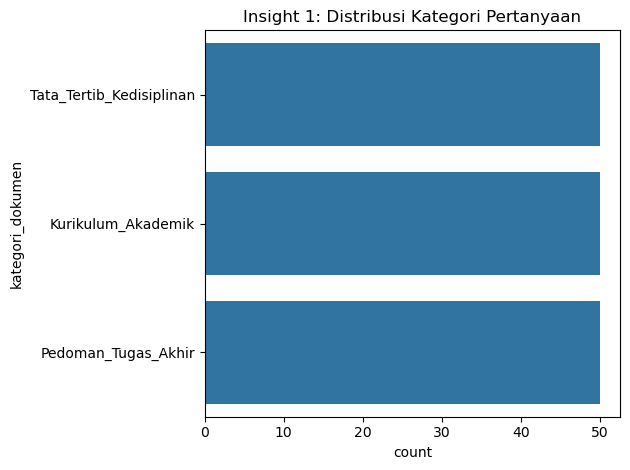

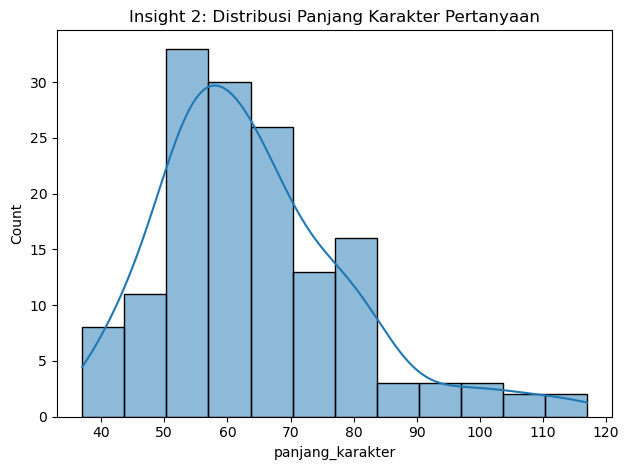

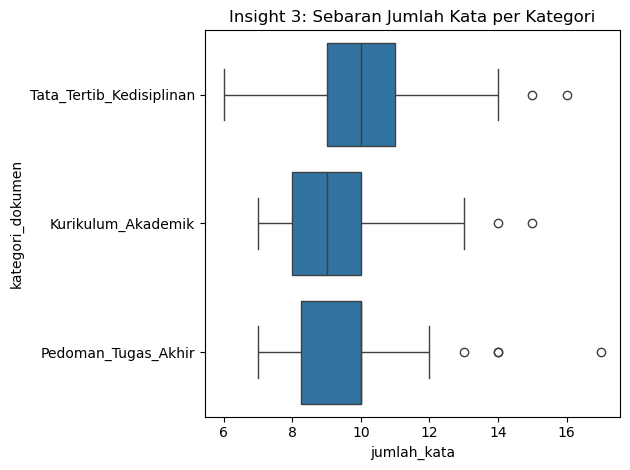

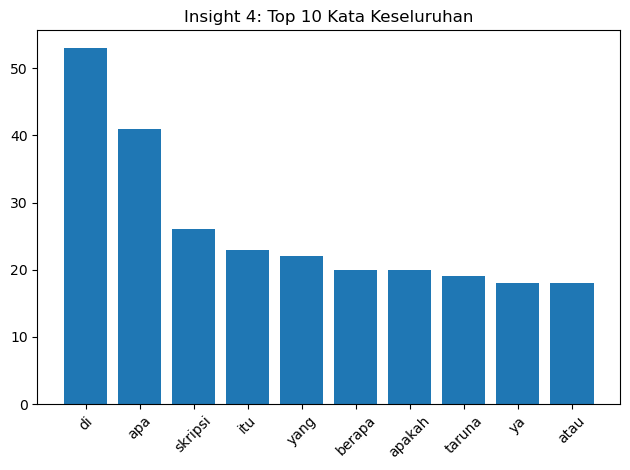

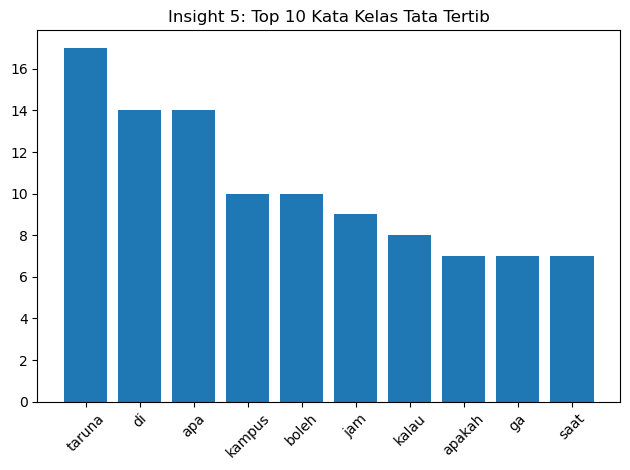


--- HASIL DATA SPLIT ---
Dimensi Training Data: (105, 516)
Dimensi Validation Data: (22, 516)
Dimensi Testing Data: (23, 516)

File preprocessing.pkl berhasil disimpan di folder models/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. LOAD DATA & ANALISIS KUALITAS DATA
# ---------------------------------------------------------
df = pd.read_csv('../data/processed/dataset_faq_stmkg.csv', sep=';')

print("--- ANALISIS KUALITAS DATA ---")
print("Missing Values:\n", df.isnull().sum())
df = df.dropna()

print("\nJumlah Duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nDistribusi Kelas:\n", df['kategori_dokumen'].value_counts())

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING (TEXT CLEANING)
# ---------------------------------------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Hapus tanda baca
    text = re.sub(r'\d+', '', text)     # Hapus angka
    return text

df['teks_bersih'] = df['teks_pertanyaan'].apply(clean_text)
df['panjang_karakter'] = df['teks_pertanyaan'].apply(len)
df['jumlah_kata'] = df['teks_pertanyaan'].apply(lambda x: len(str(x).split()))

# ---------------------------------------------------------
# 3. VISUALISASI 5 INSIGHTS KUNCI (DEFAULT STYLE)
# ---------------------------------------------------------
# Insight 1: Distribusi Kelas Target
plt.figure()
sns.countplot(data=df, y='kategori_dokumen')
plt.title('Insight 1: Distribusi Kategori Pertanyaan')
plt.tight_layout()
plt.show()

# Insight 2: Distribusi Panjang Karakter
plt.figure()
sns.histplot(df['panjang_karakter'], kde=True)
plt.title('Insight 2: Distribusi Panjang Karakter Pertanyaan')
plt.tight_layout()
plt.show()

# Insight 3: Deteksi Outlier Jumlah Kata per Kategori
plt.figure()
sns.boxplot(data=df, x='jumlah_kata', y='kategori_dokumen')
plt.title('Insight 3: Sebaran Jumlah Kata per Kategori')
plt.tight_layout()
plt.show()

# Fungsi bantuan untuk Insight 4 & 5
def get_top_words(text_series):
    all_words = ' '.join(text_series).split()
    return Counter(all_words).most_common(10)

top_words_all = dict(get_top_words(df['teks_bersih']))
df_tatib = df[df['kategori_dokumen'] == 'Tata_Tertib_Kedisiplinan']
top_words_tatib = dict(get_top_words(df_tatib['teks_bersih']))

# Insight 4: Top 10 Kata Keseluruhan
plt.figure()
plt.bar(top_words_all.keys(), top_words_all.values())
plt.title('Insight 4: Top 10 Kata Keseluruhan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight 5: Top 10 Kata pada Kelas Tata Tertib
plt.figure()
plt.bar(top_words_tatib.keys(), top_words_tatib.values())
plt.title('Insight 5: Top 10 Kata Kelas Tata Tertib')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. PREPROCESSING (ENCODING & TF-IDF)
# ---------------------------------------------------------
le = LabelEncoder()
y_target = le.fit_transform(df['kategori_dokumen'])

tfidf = TfidfVectorizer(max_features=1000)
X_features = tfidf.fit_transform(df['teks_bersih']).toarray()

# Simpan objek preprocessing untuk deployment Streamlit nanti
with open('../models/preprocessing.pkl', 'wb') as f:
    pickle.dump({'vectorizer': tfidf, 'encoder': le}, f)

# ---------------------------------------------------------
# 5. PEMBAGIAN DATASET (TRAIN-VALIDATION-TEST SPLIT)
# ---------------------------------------------------------
# Pisahkan 70% Train, 30% untuk sisa
X_train, X_temp, y_train, y_temp = train_test_split(
    X_features, y_target, test_size=0.30, random_state=42, stratify=y_target
)

# Pisahkan sisa 30% menjadi 15% Validation dan 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n--- HASIL DATA SPLIT ---")
print(f"Dimensi Training Data: {X_train.shape}")
print(f"Dimensi Validation Data: {X_val.shape}")
print(f"Dimensi Testing Data: {X_test.shape}")
print("\nFile preprocessing.pkl berhasil disimpan di folder models/")
